In [1]:
# Import libraries
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
from muon import atac as ac


/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
#Load the h5mu MU object that was saved after processing the scRNA data
mdata = mu.read("../data/pbmc10k/pbmc10k.h5mu")
mdata

/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 10691 × 140869
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	9242 × 25690
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	10691 × 115179
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

In [3]:

atac = mdata.mod['atac'] #Isolate the atac seq modality as a seprate AnnData object
rna = mdata.mod['rna']

#Manually add the atac peak annotation. This tsv file links each peak with the nearest gene.
ac.tl.add_peak_annotation(atac, annotation="../data/pbmc10k/10k_PBMC_Multiome_nextgem_Chromium_Controller_atac_peak_annotation.tsv")

atac  # an AnnData object

/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/muon/_atac/tools.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pa.loc[pa.distance.isnull(), "distance"] = ""


AnnData object with n_obs × n_vars = 10691 × 115179
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
    uns: 'atac'

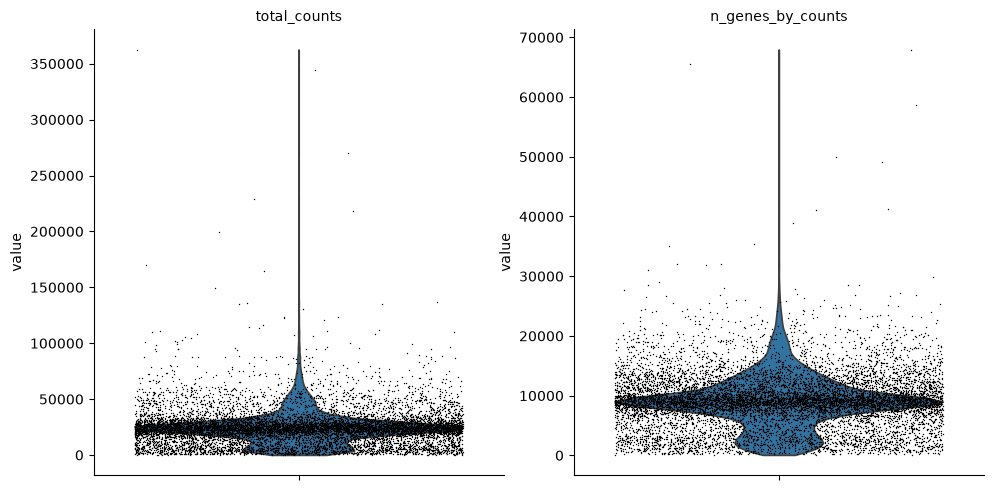

In [4]:
#Compute a set of metrics for both obs and var of the object
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['total_counts', 'n_genes_by_counts'], jitter=0.4, multi_panel=True)



Filtering

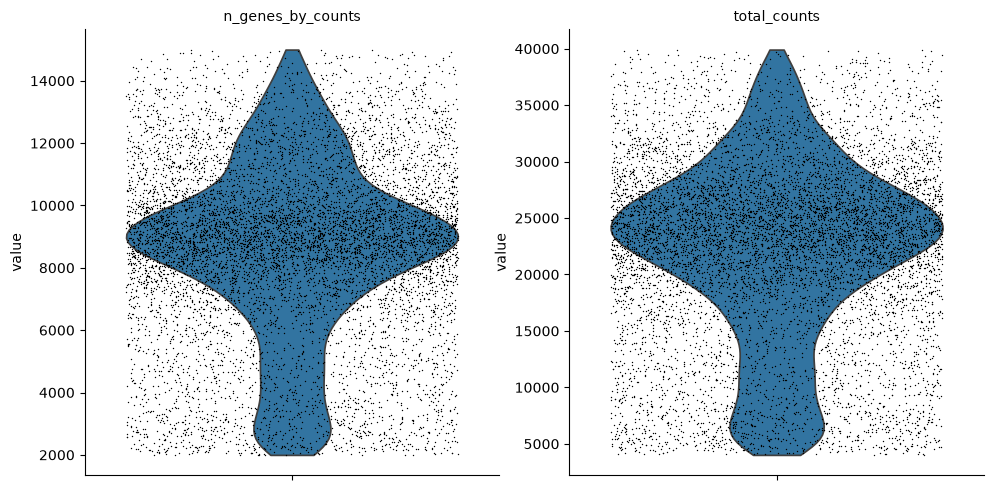

In [5]:
# Keep only peaks that are detected in at least 10 cells.
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)

# Keep only cells with more than 2000 peaks but less than 15000 peaks
mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 2000) & (x <= 15000))

# Keep only cells with more than 4000 counts but less than 40000
mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 4000) & (x <= 40000))

# #Plot the filtered data as violin plot
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)


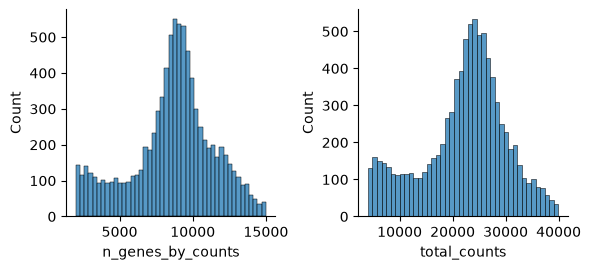

In [6]:
#Plot the qc metrics in histogram format
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'])


In [7]:
#Manually add the path to the atac fragments files
atac.uns["files"] = {
    "fragments": "../data/pbmc10k/10k_PBMC_Multiome_nextgem_Chromium_Controller_atac_fragments.tsv.gz",
    "peak_annotation" : "../data/pbmc10k/10k_PBMC_Multiome_nextgem_Chromium_Controller_atac_peak_annotation.tsv"
}

In [8]:
atac.obs

,n_genes_by_counts,total_counts
AAACAGCCAACAACAA-1,5637,13907.0
AAACAGCCAAGGACCA-1,7518,18448.0
AAACAGCCACAATGCC-1,9124,24482.0
AAACATGCAAGATTCT-1,5090,11355.0
AAACATGCACAACAAA-1,8250,21322.0
...,...,...
TTTGTGTTCAAGCGCC-1,7607,18858.0
TTTGTGTTCGTTTCCA-1,11488,27739.0
TTTGTTGGTACCCACC-1,8735,22613.0
TTTGTTGGTACCGAAC-1,11302,28082.0


In [9]:
#Initialize a dummy nucleosome signal column in atac.obs
# atac.obs['NS']=1


Fetching Regions...:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching Regions...: 100%|██████████| 1/1 [00:02<00:00,  2.60s/it]


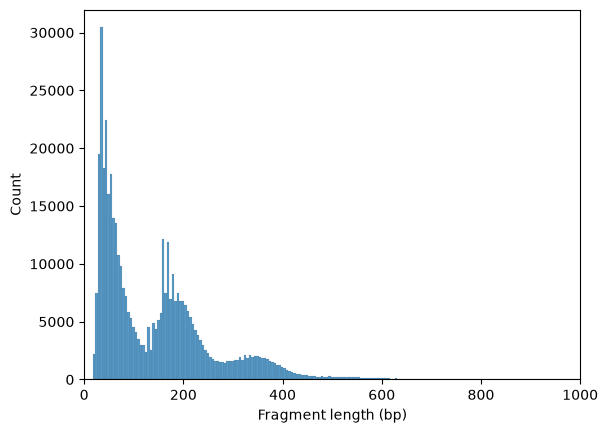

In [10]:
ac.pl.fragment_histogram(atac, region='chr1:1-2000000')

In [11]:
atac.obs

,n_genes_by_counts,total_counts
AAACAGCCAACAACAA-1,5637,13907.0
AAACAGCCAAGGACCA-1,7518,18448.0
AAACAGCCACAATGCC-1,9124,24482.0
AAACATGCAAGATTCT-1,5090,11355.0
AAACATGCACAACAAA-1,8250,21322.0
...,...,...
TTTGTGTTCAAGCGCC-1,7607,18858.0
TTTGTGTTCGTTTCCA-1,11488,27739.0
TTTGTTGGTACCCACC-1,8735,22613.0
TTTGTTGGTACCGAAC-1,11302,28082.0


Reading Fragments:   4%|▍         | 38034/1000000 [00:00<00:02, 380314.97it/s]

Reading Fragments: 100%|██████████| 1000000/1000000 [00:02<00:00, 386200.58it/s]


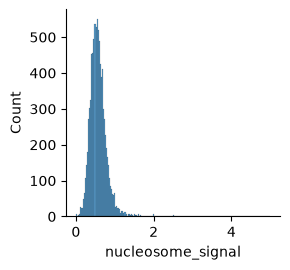

In [12]:
#Compute the nucleosome signal per cell
ac.tl.nucleosome_signal(atac, n=1e6) #n is for number of fragments to count. If None, 1e4 fragments * number of cells.

#Plot the nucleosome signal per cell
mu.pl.histogram(atac, "nucleosome_signal", kde=False)



In [13]:
# Just retrieve the gene coordinates form the rna modality
ac.tl.get_gene_annotation_from_rna(mdata['rna']).head(3)  # accepts MuData with 'rna' modality or mdata['rna'] AnnData directly


,Chromosome,Start,End,gene_id,gene_name
AL627309.1,chr1,120931,133723,ENSG00000238009,AL627309.1
AL627309.5,chr1,149706,173862,ENSG00000241860,AL627309.5
AL627309.4,chr1,160445,160446,ENSG00000241599,AL627309.4


Fetching Regions...:   0%|          | 4/1000 [00:00<00:26, 37.36it/s]

Fetching Regions...: 100%|██████████| 1000/1000 [00:19<00:00, 51.48it/s]
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


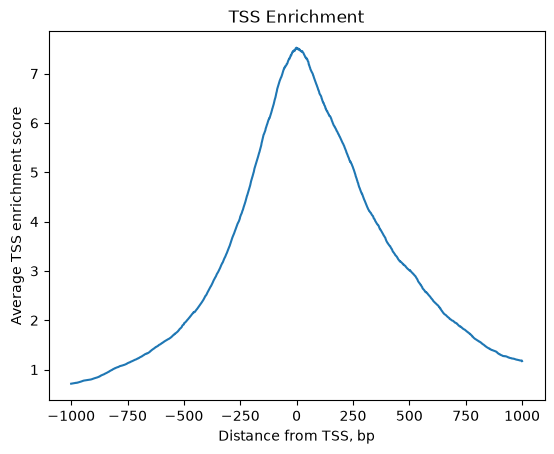

In [14]:
#Compute the tss enicment
tss = ac.tl.tss_enrichment(mdata, n_tss=1000)  # by default, features=ac.tl.get_gene_annotation_from_rna(mdata)
# n_tss -> How many randomly chosen TSS sites to pile up. The fewer the faster. Default: 2000.

#Plot the average tss enrichment score
ac.pl.tss_enrichment(tss)


In [15]:
# Save original counts
atac.layers["counts"] = atac.X



In [16]:
#Apply tfidf
ac.pp.tfidf(atac, scale_factor=1e4)

# Normalize counts so all cells have a sum of 10000 counts
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)

# Log transform the counts
sc.pp.log1p(atac)

/tmp/ipykernel_1648515/233484533.py:5: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [17]:
# Extract highly variable features
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=0.5)

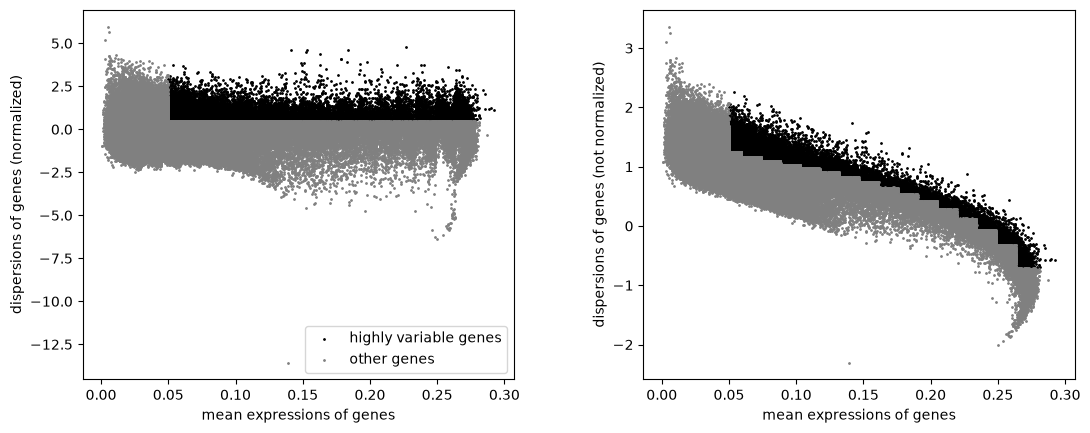

In [18]:
# Plot the highly variable genes
sc.pl.highly_variable_genes(atac)


In [19]:
np.sum(atac.var.highly_variable)

np.int64(20850)

In [20]:
# Save the log transformed-normalized data to a slot
atac.raw = atac


In [21]:
# Perform LSI
ac.tl.lsi(atac)

In [22]:
atac.obsm['X_lsi'].shape

(8817, 50)

In [23]:
atac.varm["LSI"]

array([[-7.8058027e-04, -1.6584234e-04,  1.6023174e-03, ...,
        -4.6616298e-04,  1.2841191e-03, -1.9073234e-03],
       [-1.1283796e-03, -1.7132290e-04,  1.9834198e-03, ...,
         4.4131228e-03,  1.5354613e-03, -4.3857814e-04],
       [-7.9096603e-04, -3.3619499e-04,  5.7463732e-04, ...,
        -5.5635214e-04,  1.5736039e-03,  8.5748243e-04],
       ...,
       [-3.3777329e-04,  3.2735057e-04,  2.9883135e-04, ...,
        -3.1029484e-03,  9.3236427e-05, -1.2899793e-03],
       [-8.7628252e-04, -2.7151281e-04,  9.1625945e-05, ...,
        -5.5663812e-04,  1.4007059e-03,  6.1263400e-04],
       [-3.9660081e-04,  8.4438716e-04,  3.2936918e-04, ...,
         8.0090249e-04, -1.6201711e-05, -1.0132156e-04]],
      shape=(115151, 50), dtype=float32)

In [24]:
#The first component is typically associated with number of peaks or counts per cell so it is reasonable to remove it
atac.obsm['X_lsi'] = atac.obsm['X_lsi'][:,1:]
atac.varm["LSI"] = atac.varm["LSI"][:,1:]
atac.uns["lsi"]["stdev"] = atac.uns["lsi"]["stdev"][1:]

In [25]:

# Compute the neighbor graph
# By default a knn graph is computed based on the eycledian distance of the entries in the given matrix
sc.pp.neighbors(atac, use_rep="X_lsi", n_neighbors=10, n_pcs=30) 

In [26]:
#Scale the data
sc.pp.scale(atac)

#Perform PCA
sc.tl.pca(atac)

/home/ktsomakian/miniconda3/envs/scanpy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


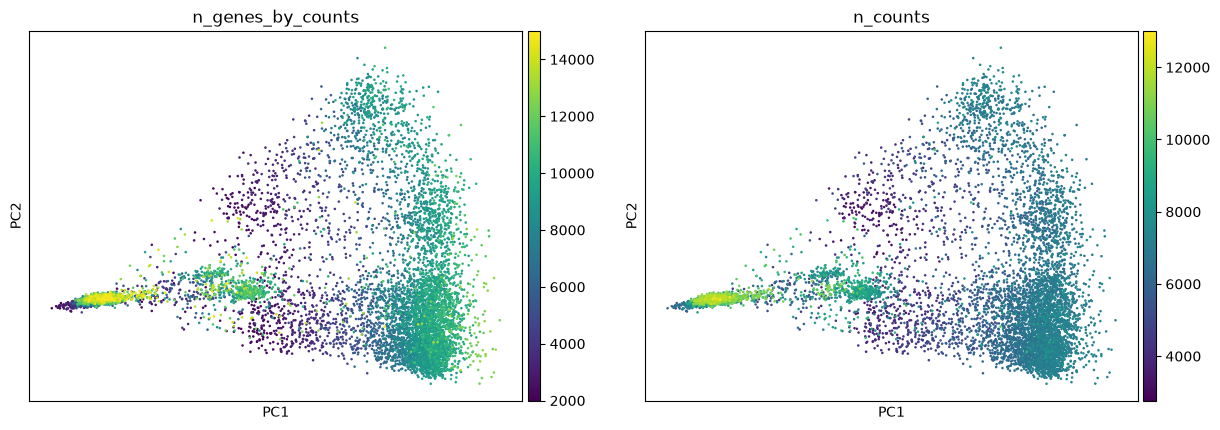

In [27]:
#Perform PCA and color cells based on the number of peaks and the the number of total reads
sc.pl.pca(atac, color=["n_genes_by_counts", "n_counts"])


In [28]:
set(atac.uns['atac']['peak_annotation']['peak_type'].to_list())

{'distal', 'intergenic', 'promoter'}

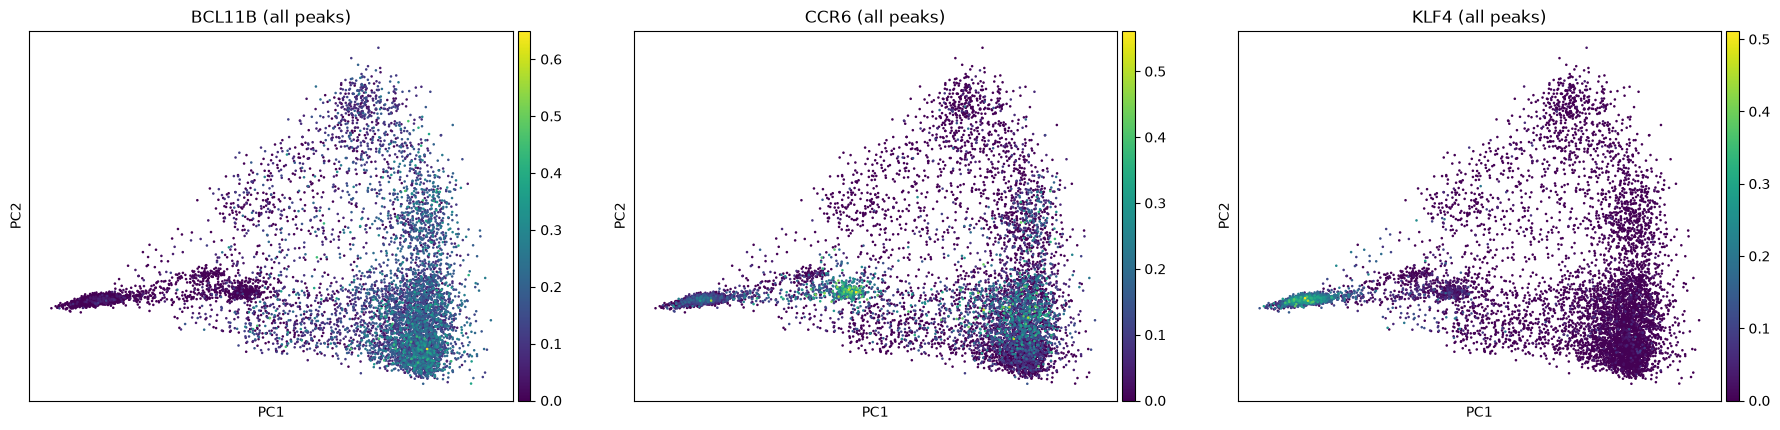

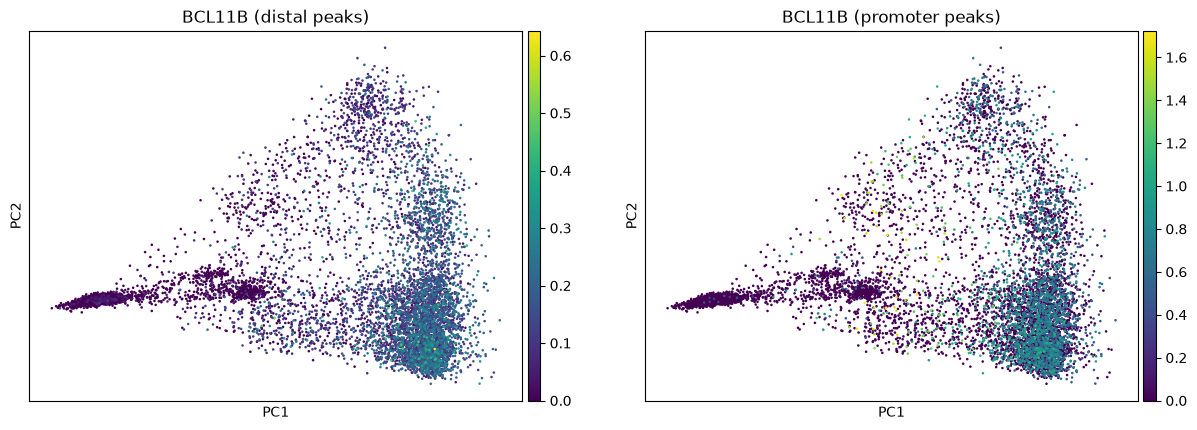

In [29]:
#Plot the PCA and color cells based on th expression of the given genes
ac.pl.pca(atac, color=["BCL11B", "CCR6", "KLF4"], average="total") #average = 'total' means to consider all the peaks that are linked to the gene
ac.pl.pca(atac, color="BCL11B", average="peak_type") #average = 'peak_type' means to consider seperately the different peaks(distal/promoter) that are linked to the gene


In [30]:
#Compute the neighbors
sc.pp.neighbors(atac, n_neighbors=10, n_pcs=30)


/tmp/ipykernel_1648515/3156342286.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(atac, resolution=.5)


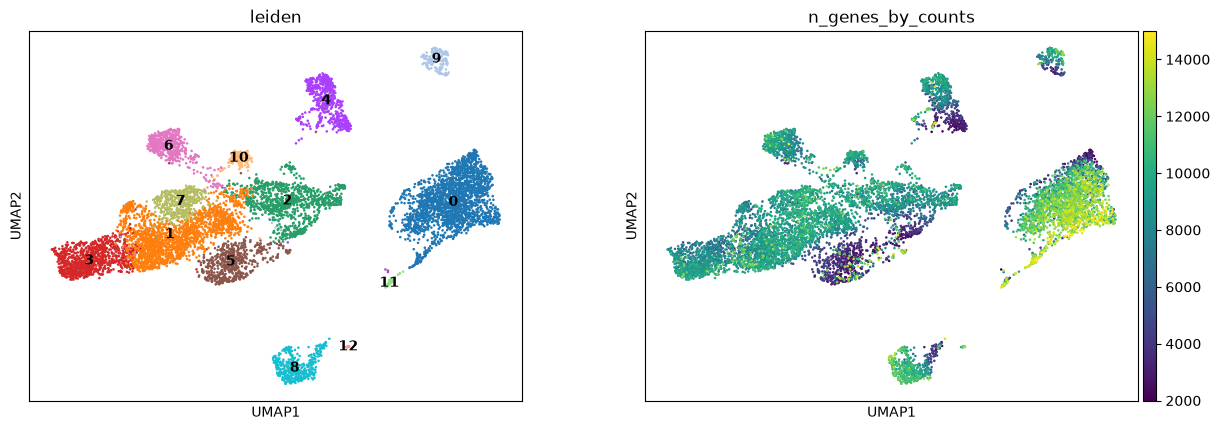

In [31]:
#Cluster the cells
sc.tl.leiden(atac, resolution=.5)

#UMAP projection
sc.tl.umap(atac, spread=1.5, min_dist=.5, random_state=20)

#UMAP plot
sc.pl.umap(atac, color=["leiden", "n_genes_by_counts"], legend_loc="on data")


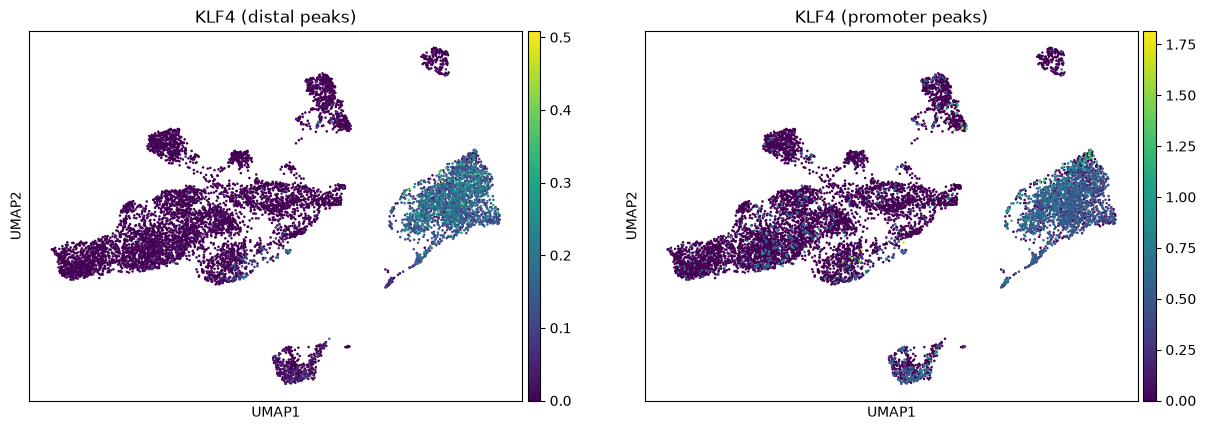

In [32]:
ac.pl.umap(atac, color=["KLF4"], average="peak_type")


Identfy cell types based on peak accesibility

In [33]:
# Run differential peak accessibility analysis between clusters
ac.tl.rank_peaks_groups(atac, 'leiden', method='t-test')


In [34]:
#Prin the top marker peaks for each cluster
result = atac.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.set_option("display.max_columns", 50)
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'genes', 'pvals']}).head(10)

,0_n,0_g,0_p,1_n,1_g,1_p,2_n,2_g,2_p,3_n,3_g,3_p,4_n,4_g,4_p,5_n,5_g,5_p,6_n,6_g,6_p,7_n,7_g,7_p,8_n,8_g,8_p,9_n,9_g,9_p,10_n,10_g,10_p,11_n,11_g,11_p,12_n,12_g,12_p
0,chr6:44058435-44059439,"AL109615.2, AL109615.3",0.0,chr12:119988558-119989458,BICDL1,3.337329e-159,chr2:86785945-86786677,CD8A,1.135531e-97,chr21:45642971-45643873,PCBP3,1.214649e-122,chr17:83083339-83084279,METRNL,1.105874e-68,chr11:64240854-64241710,"FKBP2, AP001453.3",0.000002,chr19:50724557-50725451,CLEC11A,9.524568e-74,chr6:161076037-161076964,"MAP3K4, AL139393.3",1.379428e-69,chr16:88045652-88046576,"BANP, AC134312.3",2.838397e-88,chr3:93470134-93471048,,1.266735e-58,chr11:114065791-114066720,ZBTB16,9.634810e-26,chr3:194396862-194397605,GP5,2.721272e-13,chr20:10433753-10434736,MKKS,0.000002
1,chr20:50274643-50275556,SMIM25,0.0,chr1:6460079-6460930,"TNFRSF25, ESPN",3.544073e-130,chr16:23482553-23483387,GGA2,1.726578e-84,chr17:82126431-82127361,CCDC57,1.738048e-111,chr4:8409185-8410113,ACOX3,4.012962e-63,chr1:228165310-228166286,IBA57,0.000011,chr6:111086973-111087873,SLC16A10,6.139716e-53,chr6:167113952-167114832,CCR6,2.261570e-60,chr14:64235496-64236423,"SYNE2, ESR2",1.482777e-82,chr6:146543207-146544113,RAB32,2.037018e-31,chr17:82909284-82910196,"TBCD, AC087222.1",4.295032e-21,chr1:36175021-36175952,MAP7D1,5.465346e-11,chr18:51153658-51154564,MEX3C,0.000005
2,chr6:13302499-13303432,AL008729.1,0.0,chr11:126062602-126063505,CDON,3.885636e-105,chr17:47829593-47830456,MRPL10,3.519690e-83,chr2:109031495-109032434,EDAR,1.191965e-89,chr12:52566624-52567526,KRT74,3.603409e-59,chr12:119988558-119989458,BICDL1,0.000011,chr11:66317713-66318555,"CD248, AP001107.3",1.994766e-52,chr1:57307135-57308047,DAB1,4.520373e-59,chr2:231672405-231673238,PTMA,3.186152e-78,chr3:128415145-128415878,DNAJB8-AS1,3.881056e-31,chr1:57307135-57308047,DAB1,4.807220e-21,chr7:98641558-98642493,NPTX2,5.686757e-11,chr9:90774392-90775204,SYK,0.000007
3,chr17:78442418-78443327,"DNAH17, DNAH17-AS1",0.0,chr9:33415217-33416125,AL356218.2,6.089452e-101,chr14:92531176-92532066,RIN3,1.811433e-82,chr15:97960058-97960959,ARRDC4,9.854447e-86,chr22:23263706-23264628,"BCR, LINC02556",8.752944e-59,chr3:9396526-9397758,"SETD5, THUMPD3-AS1",0.000012,chr17:82126431-82127361,CCDC57,1.334933e-50,chr15:90856440-90857333,FURIN,4.717885e-51,chr10:48671212-48672113,AC068898.1,8.201312e-76,chr19:21593884-21594767,AC123912.2,1.331224e-30,chr11:114073548-114074443,ZBTB16,6.532996e-21,chr6:4281532-4282451,AL159166.1,1.596465e-10,chr2:96335365-96336282,NCAPH,0.000009
4,chr9:107489486-107490392,KLF4,0.0,chr2:218879944-218880886,WNT10A,1.339276e-93,chr1:24910850-24911751,RUNX3,1.573583e-76,chr11:60985913-60986814,CD6,2.462171e-78,chr17:36066306-36067222,CCL18,1.561233e-54,chr9:93095456-93096377,"AL451065.1, CARD19",0.000043,chr19:5130188-5131107,"AC022517.1, KDM4B",4.859268e-47,chr7:44633431-44634239,OGDH,9.274903e-51,chr1:160789570-160790453,LY9,2.177223e-74,chr19:40330807-40331683,C19orf47,3.607040e-27,chr15:90856440-90857333,FURIN,3.006347e-20,chr22:46239261-46240151,"PPARA, CDPF1",2.317312e-10,chr3:143119261-143120131,CHST2,0.000012
5,chr9:134371489-134372329,RXRA,0.0,chr1:23619252-23620154,"AL450043.1, MDS2",1.660510e-91,chr2:241762712-241763647,"D2HGDH, AC114730.2",5.214251e-76,chr20:5714323-5715243,SHLD1,2.754837e-76,chr12:121557439-121558354,KDM2B,1.418777e-54,chr19:6424681-6425578,KHSRP,0.000044,chr1:59814304-59815212,HOOK1,1.370144e-46,chr4:86593835-86594704,"MAPK10, PTPN13",8.187824e-50,chr22:41935970-41936869,CENPM,4.087934e-73,chr19:13102584-13103481,LYL1,7.277357e-27,chr5:133466997-133467890,"AC010608.1, FSTL4",1.801017e-19,chr17:16980940-16981689,AC104024.1,2.813459e-10,chr19:2663842-2664761,"GNG7, AC092068.3",0.000015
6,chr17:78198679-78199610,AFMID,0.0,chr2:218896452-218897281,WNT10A,5.623633e-91,chr4:8409185-8410113,ACOX3,1.463729e-75,chr1:59814304-59815212,HOOK1,1.419954e-75,chr13:24618221-24619122,ATP12A,4.889349e-49,chr18:79068732-79069646,ATP9B,0.000083,chr1:48776444-48777357,"BEND5, AGBL4",3.802647e

In [35]:
# If I study the marker peaks ant the realted peaks of each cluster I can see that some clusters can either be doublets, or proliferating cells or stressed cells.
# If I identify such clusters I can remove them
mu.pp.filter_obs(atac, "leiden", lambda x: ~x.isin(["2", "5", "11", "12"]))
# Analogous to
#   atac = atac[~atac.obs.leiden.isin(["10", "14", "15", "16"])]
# but doesn't copy the object	

In [36]:
# Rename the clusters
new_cluster_names = {
    "0": "CD8+ T / MAIT-like",
    "1": "CD4+ memory T",
    "3": "MAIT / NKT-like",
    "4": "activated cytotoxic T",
    "6": "CD4+ memory / Th17-like",
    "7": "NK",
    "8": "CD8+ effector T",
    "9": "CD8+ cytotoxic T",
    "10": "MAIT-like"
}

atac.obs['celltype'] = atac.obs.leiden.astype("str").values
atac.obs.celltype = atac.obs.celltype.astype("category").cat.rename_categories(new_cluster_names)

In [37]:
set(atac.obs['celltype'].to_list())

{'CD4+ memory / Th17-like',
 'CD4+ memory T',
 'CD8+ T / MAIT-like',
 'CD8+ cytotoxic T',
 'CD8+ effector T',
 'MAIT / NKT-like',
 'MAIT-like',
 'NK',
 'activated cytotoxic T'}

In [40]:
# #Reorder them
# atac.obs.celltype.cat.reorder_categories([
#     'CD4+ naïve T', 'CD4+ memory T', 'MAIT',
#     'CD8+ naïve T', 'CD8+ activated T', 'NK',
#     'naïve B', 'memory B',
#     'CD14 mono', 'intermediate mono', 'CD16 mono',
#     'mDC'], ordered=True)

In [41]:
import matplotlib
import matplotlib.pyplot as plt

cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, len(atac.obs.celltype.cat.categories)))

atac.uns["celltype_colors"] = list(map(matplotlib.colors.to_hex, colors))

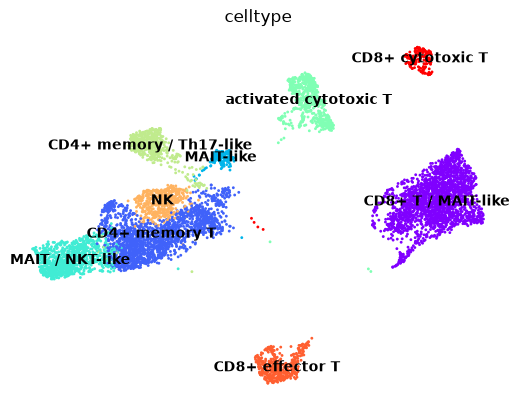

In [42]:
sc.pl.umap(atac, color="celltype", legend_loc="on data", frameon=False)


In [43]:
marker_genes = ['IL7R', 'TRAC',
                'GATA3',
                'SLC4A10',
                'CD8A', 'CD8B', 'CD248', 'CCL5',
                'GNLY', 'NKG7',
                'CD79A', 'MS4A1', 'IGHD', 'IGHM', 'TNFRSF13C',
                'IL4R', 'KLF4', 'LYZ', 'S100A8', 'ITGAM', 'CD14',
                'FCGR3A', 'MS4A7', 'CST3',
                'CLEC10A', 'IRF8', 'TCF4']

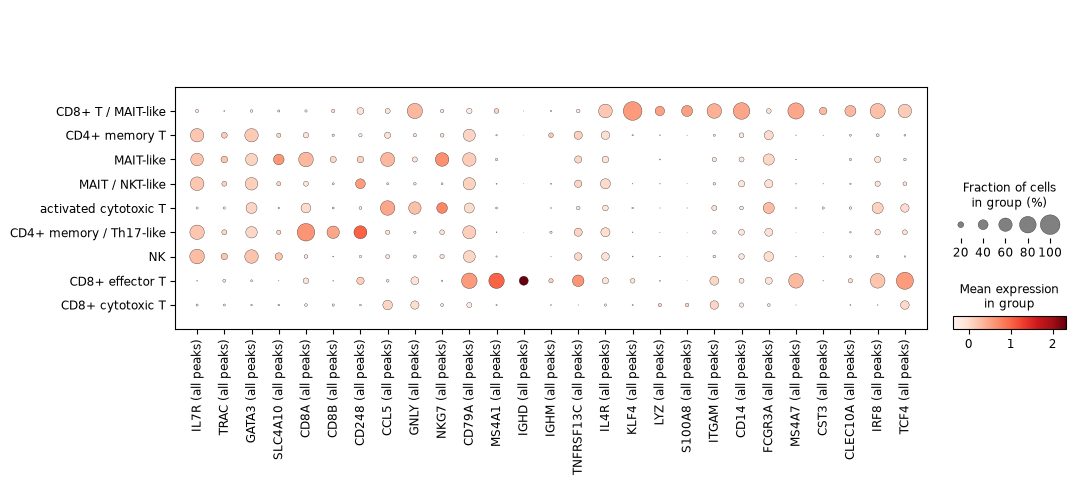

In [44]:
ac.pl.dotplot(atac, marker_genes, groupby='celltype')


Make sure that the final object has the exact same cells in both the rna and the atac modality

In [45]:
rna_cells = mdata['rna'].obs.index
atac_cells = mdata['atac'].obs.index
print(f'{len(rna_cells)} cells were kept after proccessing rna data and {len(atac_cells)} cells were kept after processing atac data.')
common_cells = np.intersect1d(rna_cells, atac_cells)
print(f'{len(common_cells)} cells were in common between the two!')

9242 cells were kept after proccessing rna data and 7191 cells were kept after processing atac data.
6387 cells were in common between the two!


In [46]:
#Filter so both modalities have only common cells
atac = atac[atac.obs_names.isin(common_cells)].copy()
rna = rna[rna.obs_names.isin(common_cells)].copy()

#Make sure after filtering the two modalitites cells appear in the same order.
atac = atac[common_cells].copy()
rna = rna[common_cells].copy()

#Test that indeed appear in the same order.
print('Do cells in both modalities appear in the same order?:')
print((rna.obs_names == atac.obs_names).all())

Do cells in both modalities appear in the same order?:
True


For the autoecoder make sure that for both modalities only the highly variable features are included.

In [47]:
#Because rna filtering produces a smaller set of variable genes i will subset the atac variable features
# to a total of n features, where n is the total number of variable genes found in the rna data.
rna_hvg = rna.var[rna.var['highly_variable'] == True].index
atac_hvg = atac.var[atac.var['highly_variable'] == True].index[:len(rna_hvg)]
print(f'In to total there are {len(rna_hvg)} features for the rna mdality and {len(atac_hvg)} features for the atac modality.')

In to total there are 4287 features for the rna mdality and 4287 features for the atac modality.


In [48]:
rna = rna[:, rna.var.index.isin(rna_hvg)].copy()
atac = atac[:, atac.var.index.isin(atac_hvg)].copy()
print(atac.X.shape, rna.X.shape)

(6387, 4287) (6387, 4287)


In [49]:
mu.write("../data/pbmc10k/pbmc10k.h5mu/atac", atac)
mu.write("../data/pbmc10k/pbmc10k.h5mu/rna", rna)
